# Decision Tree Algorithms — ID3, C4.5, CHAID, CART
### Using a Different Dataset for Each Algorithm

Each algorithm is demonstrated on its own purpose-built dataset (4 features, 10-15 rows) so that the strengths of each method are visible:

| Algorithm | Dataset | Why this dataset |
|---|---|---|
| **ID3** | `id3_weather_dataset.csv` | All-categorical — plays to ID3's classic strength (information gain on categorical splits) |
| **C4.5** | `c45_loan_dataset.csv` | Mixed **numeric + categorical** features — shows C4.5's continuous-threshold splitting + gain ratio |
| **CHAID** | `chaid_purchase_dataset.csv` | All-categorical, multi-level features — ideal for chi-squared contingency-table tests |
| **CART** | `cart_student_dataset.csv` | Mixed numeric + categorical, with a continuous target too — shows CART's binary Gini splits for classification *and* regression |

**Sections:** 1) Setup 2) ID3 3) C4.5 4) CHAID 5) CART (classification + regression) 6) Pre/Post-Pruning 7) Evaluation (Confusion Matrix & Metrics)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

pd.set_option('display.width', 120)
np.set_printoptions(precision=3, suppress=True)

def print_tree(tree, indent=""):
    """Pretty-print a nested-dict decision tree."""
    if not isinstance(tree, dict):
        print(indent + "-> Class =", tree)
        return
    for feature, branches in tree.items():
        for value, subtree in branches.items():
            print(f"{indent}[{feature} = {value}]")
            print_tree(subtree, indent + "    ")


## (a) ID3 Tree — Information Gain (Entropy)

**Dataset:** `id3_weather_dataset.csv` — Outlook, Temperature, Humidity, Wind → Play (Yes/No). 14 rows, all categorical — the classic use case for ID3.

**Algorithm:** at each node pick the feature with highest **Information Gain**:
$$Entropy(S) = -\sum_i p_i \log_2(p_i) \qquad Gain(S,A) = Entropy(S) - \sum_v \frac{|S_v|}{|S|}Entropy(S_v)$$


In [2]:
df_id3 = pd.read_csv("id3_weather_dataset.csv").drop(columns=["Day"])
feats_id3 = ["Outlook", "Temperature", "Humidity", "Wind"]
target_id3 = "Play"
df_id3


,Outlook,Temperature,Humidity,Wind,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [3]:
def entropy(col):
    vals, counts = np.unique(col, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs))

def info_gain(data, feature, target):
    total_entropy = entropy(data[target])
    vals, counts = np.unique(data[feature], return_counts=True)
    weighted = sum((c/len(data)) * entropy(data[data[feature]==v][target]) for v, c in zip(vals, counts))
    return total_entropy - weighted

def id3(data, features, target, depth=0, max_depth=None):
    classes = data[target].unique()
    if len(classes) == 1:
        return classes[0]
    if len(features) == 0 or (max_depth is not None and depth >= max_depth):
        return data[target].mode()[0]
    gains = {f: info_gain(data, f, target) for f in features}
    best = max(gains, key=gains.get)
    tree = {best: {}}
    for v in data[best].unique():
        subset = data[data[best]==v].drop(columns=[best])
        remaining = [f for f in features if f != best]
        tree[best][v] = id3(subset, remaining, target, depth+1, max_depth)
    return tree

print("Information Gain at root:", {f: round(info_gain(df_id3, f, target_id3), 4) for f in feats_id3})

id3_tree = id3(df_id3, feats_id3, target_id3)
print("\nID3 DECISION TREE")
print_tree(id3_tree)


Information Gain at root: {'Outlook': np.float64(0.2467), 'Temperature': np.float64(0.0292), 'Humidity': np.float64(0.1518), 'Wind': np.float64(0.0481)}

ID3 DECISION TREE
[Outlook = Sunny]
    [Humidity = High]
        -> Class = No
    [Humidity = Normal]
        -> Class = Yes
[Outlook = Overcast]
    -> Class = Yes
[Outlook = Rain]
    [Wind = Weak]
        -> Class = Yes
    [Wind = Strong]
        -> Class = No


## (b) C4.5 Tree — Gain Ratio (with Continuous Features)

**Dataset:** `c45_loan_dataset.csv` — Income (numeric), Credit_Score (numeric), Employment_Type (categorical), Debt_Level (categorical) → Loan_Approved. 14 rows.

**Algorithm:** C4.5 improves on ID3 in two key ways demonstrated here:
1. **Gain Ratio** instead of raw Information Gain (normalizes by Split Information, penalizing features with many values):
   $$GainRatio(S,A) = \frac{Gain(S,A)}{SplitInfo(S,A)}$$
2. **Handles continuous attributes** by searching for the best binary threshold split (e.g. `Income <= 54`) rather than requiring pre-discretized categories.


In [4]:
df_c45 = pd.read_csv("c45_loan_dataset.csv").drop(columns=["AppID"])
feats_c45 = ["Income_Thousands", "Credit_Score", "Employment_Type", "Debt_Level"]
target_c45 = "Loan_Approved"
numeric_feats_c45 = {"Income_Thousands", "Credit_Score"}
df_c45


,Income_Thousands,Credit_Score,Employment_Type,Debt_Level,Loan_Approved
0,25,580,Self-Employed,High,No
1,85,720,Salaried,Low,Yes
2,42,610,Self-Employed,Medium,No
3,95,780,Salaried,Low,Yes
4,30,600,Business,High,No
5,60,690,Salaried,Medium,Yes
6,110,800,Business,Low,Yes
7,35,560,Self-Employed,High,No
8,70,705,Salaried,Medium,Yes
9,28,615,Business,Medium,No


In [5]:
def best_numeric_split(data, feature, target):
    """Best binary threshold split (by gain ratio) for a numeric feature."""
    values = sorted(data[feature].unique())
    if len(values) < 2:
        return 0, None
    total_entropy = entropy(data[target])
    best_gr, best_t = 0, None
    for i in range(len(values) - 1):
        t = (values[i] + values[i+1]) / 2
        left, right = data[data[feature] <= t], data[data[feature] > t]
        if len(left) == 0 or len(right) == 0:
            continue
        weighted = (len(left)/len(data))*entropy(left[target]) + (len(right)/len(data))*entropy(right[target])
        gain = total_entropy - weighted
        p_l, p_r = len(left)/len(data), len(right)/len(data)
        si = -(p_l*np.log2(p_l) + p_r*np.log2(p_r))
        gr = gain/si if si != 0 else 0
        if gr > best_gr:
            best_gr, best_t = gr, t
    return best_gr, best_t

def categorical_gain_ratio(data, feature, target):
    total_entropy = entropy(data[target])
    vals, counts = np.unique(data[feature], return_counts=True)
    weighted = sum((c/len(data))*entropy(data[data[feature]==v][target]) for v, c in zip(vals, counts))
    gain = total_entropy - weighted
    probs = counts / counts.sum()
    si = -np.sum(probs * np.log2(probs))
    return gain / si if si != 0 else 0

def c45(data, features, target, depth=0, max_depth=None):
    classes = data[target].unique()
    if len(classes) == 1:
        return classes[0]
    if len(features) == 0 or (max_depth is not None and depth >= max_depth):
        return data[target].mode()[0]

    best_feat, best_gr, best_type, best_thresh = None, -1, None, None
    for f in features:
        if f in numeric_feats_c45:
            gr, t = best_numeric_split(data, f, target)
            if t is not None and gr > best_gr:
                best_feat, best_gr, best_type, best_thresh = f, gr, "numeric", t
        else:
            gr = categorical_gain_ratio(data, f, target)
            if gr > best_gr:
                best_feat, best_gr, best_type, best_thresh = f, gr, "categorical", None

    if best_feat is None:
        return data[target].mode()[0]

    remaining = [f for f in features if f != best_feat]
    if best_type == "numeric":
        left = data[data[best_feat] <= best_thresh]
        right = data[data[best_feat] > best_thresh]
        tree = {f"{best_feat} <= {best_thresh}": {
            "True":  c45(left, remaining, target, depth+1, max_depth),
            "False": c45(right, remaining, target, depth+1, max_depth)
        }}
    else:
        tree = {best_feat: {}}
        for v in data[best_feat].unique():
            subset = data[data[best_feat]==v].drop(columns=[best_feat])
            tree[best_feat][v] = c45(subset, remaining, target, depth+1, max_depth)
    return tree

print("Gain Ratio at root:")
for f in feats_c45:
    if f in numeric_feats_c45:
        gr, t = best_numeric_split(df_c45, f, target_c45)
        print(f"  {f}: gain_ratio={gr:.4f}  best_threshold={t}")
    else:
        print(f"  {f}: gain_ratio={categorical_gain_ratio(df_c45, f, target_c45):.4f}")

c45_tree = c45(df_c45, feats_c45, target_c45)
print("\nC4.5 DECISION TREE")
print_tree(c45_tree)


Gain Ratio at root:
  Income_Thousands: gain_ratio=1.0000  best_threshold=54.0
  Credit_Score: gain_ratio=1.0000  best_threshold=660.0
  Employment_Type: gain_ratio=0.4528
  Debt_Level: gain_ratio=0.4141

C4.5 DECISION TREE
[Income_Thousands <= 54.0 = True]
    -> Class = No
[Income_Thousands <= 54.0 = False]
    -> Class = Yes


## (c) CHAID Tree — Chi-Squared Test of Independence

**Dataset:** `chaid_purchase_dataset.csv` — Gender, Age_Group, Income_Level, Marital_Status → Purchased (Yes/No). 15 rows, all categorical with 2-3 levels each — well suited to chi-squared contingency-table testing.

**Algorithm:** at each node, run a chi-squared test between each feature and the target. Split on the feature with the **highest chi-squared statistic**, provided its p-value is below significance threshold `alpha`.
$$\chi^2 = \sum \frac{(O-E)^2}{E}$$


In [6]:
df_chaid = pd.read_csv("chaid_purchase_dataset.csv").drop(columns=["CustID"])
feats_chaid = ["Gender", "Age_Group", "Income_Level", "Marital_Status"]
target_chaid = "Purchased"
df_chaid


,Gender,Age_Group,Income_Level,Marital_Status,Purchased
0,Male,Young,Low,Single,No
1,Female,Young,Low,Single,No
2,Female,Middle,High,Married,Yes
3,Male,Middle,Medium,Married,Yes
4,Male,Senior,Medium,Married,Yes
5,Female,Senior,Low,Single,No
6,Female,Middle,High,Single,Yes
7,Male,Young,Medium,Single,No
8,Female,Young,High,Married,Yes
9,Male,Middle,Medium,Married,Yes


In [7]:
def chi_square_stat(data, feature, target):
    ct = pd.crosstab(data[feature], data[target])
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        return 0.0, 1.0
    chi2_val, p_val, dof, expected = chi2_contingency(ct)
    return chi2_val, p_val

def chaid(data, features, target, depth=0, max_depth=None, alpha=0.9):
    classes = data[target].unique()
    if len(classes) == 1:
        return classes[0]
    if len(features) == 0 or (max_depth is not None and depth >= max_depth):
        return data[target].mode()[0]
    stats = {f: chi_square_stat(data, f, target) for f in features}
    best = max(stats, key=lambda f: stats[f][0])
    chi2_val, p_val = stats[best]
    if p_val > alpha:               # no feature significant enough -> leaf
        return data[target].mode()[0]
    tree = {best: {}}
    for v in data[best].unique():
        subset = data[data[best]==v].drop(columns=[best])
        remaining = [f for f in features if f != best]
        tree[best][v] = chaid(subset, remaining, target, depth+1, max_depth, alpha)
    return tree

print("(chi2, p-value) at root:")
for f in feats_chaid:
    chi2_val, p_val = chi_square_stat(df_chaid, f, target_chaid)
    print(f"  {f}: chi2={chi2_val:.4f}  p={p_val:.4f}")

# alpha relaxed to 0.9 because a 15-row sample gives low statistical power for chi-square tests
chaid_tree = chaid(df_chaid, feats_chaid, target_chaid, alpha=0.9)
print("\nCHAID DECISION TREE")
print_tree(chaid_tree)


(chi2, p-value) at root:
  Gender: chi2=0.5469  p=0.4596
  Age_Group: chi2=6.6667  p=0.0357
  Income_Level: chi2=11.6667  p=0.0029
  Marital_Status: chi2=0.5469  p=0.4596



CHAID DECISION TREE
[Income_Level = Low]
    -> Class = No
[Income_Level = High]
    -> Class = Yes
[Income_Level = Medium]
    [Age_Group = Middle]
        -> Class = Yes
    [Age_Group = Senior]
        -> Class = Yes
    [Age_Group = Young]
        -> Class = No


## (d) CART — Classification and Regression Tree (Gini Index)

**Dataset:** `cart_student_dataset.csv` — Study_Hours, Attendance_Percent, Assignments_Submitted, Extra_Classes → `Result` (Pass/Fail) for **classification**, and → `Final_Score` (0-100) for **regression**. 15 rows.

**Algorithm:** CART always makes **binary splits**, using **Gini impurity** for classification and **variance/MSE reduction** for regression — unlike ID3/C4.5/CHAID which can produce multi-way splits. We use scikit-learn's implementation (which is CART), encoding the one categorical feature first.
$$Gini(S) = 1 - \sum_i p_i^2$$


In [8]:
df_cart = pd.read_csv("cart_student_dataset.csv").drop(columns=["StudentID"])
feats_cart = ["Study_Hours", "Attendance_Percent", "Assignments_Submitted", "Extra_Classes"]
df_cart


,Study_Hours,Attendance_Percent,Assignments_Submitted,Extra_Classes,Final_Score,Result
0,2,60,3,No,42,Fail
1,8,95,10,Yes,88,Pass
2,3,65,4,No,48,Fail
3,6,85,8,Yes,76,Pass
4,1,55,2,No,35,Fail
5,9,98,10,Yes,93,Pass
6,4,70,5,No,54,Fail
7,7,50,3,No,55,Fail
8,5,90,9,Yes,71,Pass
9,8,60,9,Yes,85,Pass


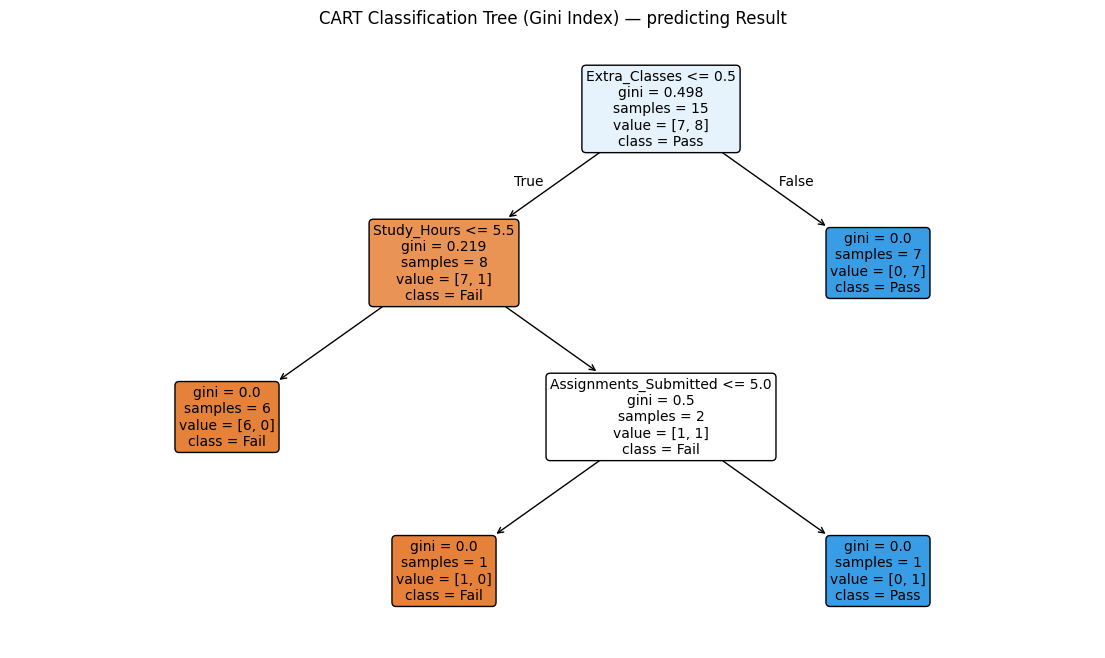

In [9]:
# ---- CART Classification: predict Result (Pass/Fail) ----
df_cart_enc = df_cart.copy()
le_extra = LabelEncoder()
df_cart_enc["Extra_Classes"] = le_extra.fit_transform(df_cart_enc["Extra_Classes"])
le_result = LabelEncoder()
df_cart_enc["Result"] = le_result.fit_transform(df_cart_enc["Result"])

X_cart = df_cart_enc[feats_cart]
y_cart = df_cart_enc["Result"]

cart_clf = DecisionTreeClassifier(criterion="gini", random_state=42)
cart_clf.fit(X_cart, y_cart)

plt.figure(figsize=(14, 8))
plot_tree(cart_clf, feature_names=feats_cart, class_names=le_result.classes_,
          filled=True, rounded=True, fontsize=10)
plt.title("CART Classification Tree (Gini Index) — predicting Result")
plt.show()


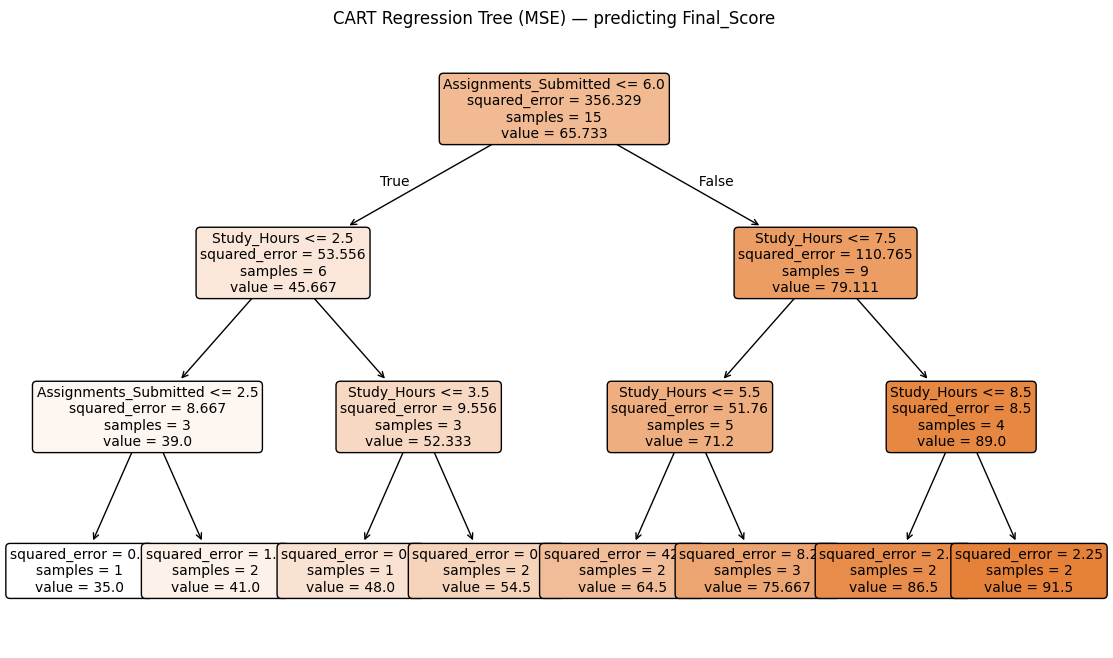

Regression tree leaf values are the *mean Final_Score* of training rows in that leaf,
versus classification trees whose leaves hold a *class label*.


In [10]:
# ---- CART Regression: predict Final_Score (continuous) ----
y_cart_reg = df_cart["Final_Score"]

cart_reg = DecisionTreeRegressor(max_depth=3, random_state=42)
cart_reg.fit(X_cart, y_cart_reg)

plt.figure(figsize=(14, 8))
plot_tree(cart_reg, feature_names=feats_cart, filled=True, rounded=True, fontsize=10)
plt.title("CART Regression Tree (MSE) — predicting Final_Score")
plt.show()

print("Regression tree leaf values are the *mean Final_Score* of training rows in that leaf,")
print("versus classification trees whose leaves hold a *class label*.")


## (e) Pre-Pruning and Post-Pruning

Reference: [GeeksforGeeks — Pruning Decision Trees](https://www.geeksforgeeks.org/pruning-decision-trees/)

Demonstrated on the **CART classification tree** (`cart_student_dataset.csv`), since scikit-learn's cost-complexity pruning API is built for CART-style trees. The same ideas (stopping early vs. growing-then-cutting-back) apply conceptually to ID3/C4.5/CHAID too.

- **Pre-pruning (early stopping):** restrict growth up front — `max_depth`, `min_samples_split`, `min_samples_leaf` — so the tree never overfits in the first place.
- **Post-pruning (cost-complexity pruning):** grow the full tree first, then prune back branches that add the least value, controlled by `ccp_alpha`.


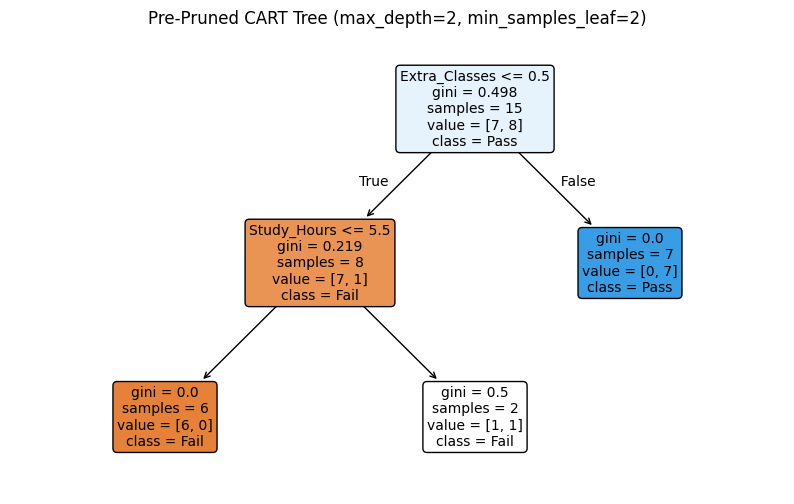

Full tree      -> depth: 3  leaves: 4
Pre-pruned tree -> depth: 2  leaves: 3


In [11]:
# ---- (i) PRE-PRUNING ----
cart_prepruned = DecisionTreeClassifier(
    criterion="gini",
    max_depth=2,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)
cart_prepruned.fit(X_cart, y_cart)

plt.figure(figsize=(10, 6))
plot_tree(cart_prepruned, feature_names=feats_cart, class_names=le_result.classes_,
          filled=True, rounded=True, fontsize=10)
plt.title("Pre-Pruned CART Tree (max_depth=2, min_samples_leaf=2)")
plt.show()

print("Full tree      -> depth:", cart_clf.get_depth(), " leaves:", cart_clf.get_n_leaves())
print("Pre-pruned tree -> depth:", cart_prepruned.get_depth(), " leaves:", cart_prepruned.get_n_leaves())


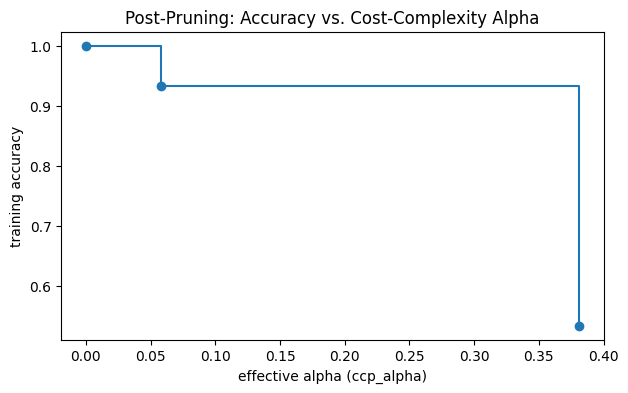

alpha values: [0.    0.058 0.381]
leaves at each alpha: [np.int64(4), np.int64(2), np.int64(1)]

Chosen ccp_alpha = 0.0583 | depth = 1 | leaves = 2


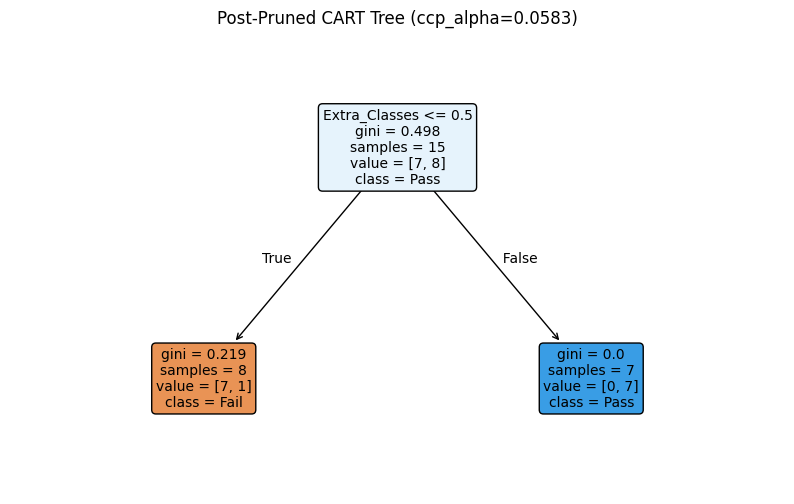

In [12]:
# ---- (ii) POST-PRUNING: cost-complexity pruning ----
path = cart_clf.cost_complexity_pruning_path(X_cart, y_cart)
ccp_alphas = path.ccp_alphas

pruned_trees = [DecisionTreeClassifier(criterion="gini", random_state=42, ccp_alpha=a).fit(X_cart, y_cart)
                for a in ccp_alphas]
train_scores = [t.score(X_cart, y_cart) for t in pruned_trees]
n_leaves = [t.get_n_leaves() for t in pruned_trees]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ccp_alphas, train_scores, marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha (ccp_alpha)")
ax.set_ylabel("training accuracy")
ax.set_title("Post-Pruning: Accuracy vs. Cost-Complexity Alpha")
plt.show()

print("alpha values:", np.round(ccp_alphas, 4))
print("leaves at each alpha:", n_leaves)

# choose a moderately pruned tree (skip the trivial single-node tree at the largest alpha)
best_idx = max(0, len(ccp_alphas) - 2)
cart_postpruned = pruned_trees[best_idx]
print(f"\nChosen ccp_alpha = {ccp_alphas[best_idx]:.4f} | depth = {cart_postpruned.get_depth()} | leaves = {cart_postpruned.get_n_leaves()}")

plt.figure(figsize=(10, 6))
plot_tree(cart_postpruned, feature_names=feats_cart, class_names=le_result.classes_,
          filled=True, rounded=True, fontsize=10)
plt.title(f"Post-Pruned CART Tree (ccp_alpha={ccp_alphas[best_idx]:.4f})")
plt.show()


## (f) Evaluation — Confusion Matrix & Metrics

Using the **CART classification model** on `cart_student_dataset.csv` with a stratified train/test split. We compute the confusion matrix and the full set of metrics: **Accuracy, Precision, Recall, Specificity, F1-score, Macro-average, Micro-average**.


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_cart, y_cart, test_size=0.33, random_state=1, stratify=y_cart
)

eval_model = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
eval_model.fit(X_train, y_train)
y_pred = eval_model.predict(X_test)

class_names = le_result.classes_   # e.g. ['Fail', 'Pass']
cm = confusion_matrix(y_test, y_pred, labels=range(len(class_names)))

print("Test set actual   :", [class_names[i] for i in y_test])
print("Test set predicted:", [class_names[i] for i in y_pred])
print()
print("Confusion Matrix (rows = actual, cols = predicted)")
print(pd.DataFrame(cm, index=[f"Actual {c}" for c in class_names],
                        columns=[f"Pred {c}" for c in class_names]))


Test set actual   : ['Pass', 'Fail', 'Pass', 'Fail', 'Pass']
Test set predicted: ['Pass', 'Fail', 'Pass', 'Fail', 'Fail']

Confusion Matrix (rows = actual, cols = predicted)
             Pred Fail  Pred Pass
Actual Fail          2          0
Actual Pass          1          2


In [14]:
def per_class_metrics(cm, class_names):
    results = []
    total = cm.sum()
    for i, name in enumerate(class_names):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = total - TP - FN - FP

        accuracy    = (TP + TN) / total if total else 0
        precision   = TP / (TP + FP) if (TP + FP) else 0
        recall      = TP / (TP + FN) if (TP + FN) else 0      # sensitivity
        specificity = TN / (TN + FP) if (TN + FP) else 0
        f1          = (2*precision*recall/(precision+recall)) if (precision+recall) else 0

        results.append({
            "Class": name, "TP": TP, "FP": FP, "FN": FN, "TN": TN,
            "Accuracy": round(accuracy, 3), "Precision": round(precision, 3),
            "Recall(Sensitivity)": round(recall, 3), "Specificity": round(specificity, 3),
            "F1-score": round(f1, 3)
        })
    return pd.DataFrame(results)

metrics_df = per_class_metrics(cm, class_names)
metrics_df


,Class,TP,FP,FN,TN,Accuracy,Precision,Recall(Sensitivity),Specificity,F1-score
0,Fail,2,1,0,2,0.8,0.667,1.000,0.667,0.8
1,Pass,2,0,1,2,0.8,1.000,0.667,1.000,0.8


In [15]:
overall_accuracy = np.trace(cm) / cm.sum()

# Macro-average: unweighted mean across classes
macro_precision = metrics_df["Precision"].mean()
macro_recall    = metrics_df["Recall(Sensitivity)"].mean()
macro_f1        = metrics_df["F1-score"].mean()

# Micro-average: pool TP/FP/FN across classes first
TP_sum, FP_sum, FN_sum = metrics_df["TP"].sum(), metrics_df["FP"].sum(), metrics_df["FN"].sum()
micro_precision = TP_sum / (TP_sum + FP_sum) if (TP_sum + FP_sum) else 0
micro_recall    = TP_sum / (TP_sum + FN_sum) if (TP_sum + FN_sum) else 0
micro_f1        = (2*micro_precision*micro_recall/(micro_precision+micro_recall)
                    if (micro_precision+micro_recall) else 0)
# Note: for single-label multiclass, micro-P = micro-R = micro-F1 = overall accuracy

summary = pd.DataFrame({
    "Metric": ["Overall Accuracy", "Macro Precision", "Macro Recall", "Macro F1",
               "Micro Precision", "Micro Recall", "Micro F1"],
    "Value":  [round(overall_accuracy,3), round(macro_precision,3), round(macro_recall,3),
               round(macro_f1,3), round(micro_precision,3), round(micro_recall,3), round(micro_f1,3)]
})
summary


,Metric,Value
0,Overall Accuracy,0.800
1,Macro Precision,0.834
2,Macro Recall,0.834
3,Macro F1,0.800
4,Micro Precision,0.800
5,Micro Recall,0.800
6,Micro F1,0.800


In [16]:
# Cross-check against scikit-learn's built-in report
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))


              precision    recall  f1-score   support

        Fail       0.67      1.00      0.80         2
        Pass       1.00      0.67      0.80         3

    accuracy                           0.80         5
   macro avg       0.83      0.83      0.80         5
weighted avg       0.87      0.80      0.80         5



### Interpretation

- **Accuracy** — overall fraction of correctly classified test samples.
- **Precision** — of samples *predicted* as a class, how many actually belong to it (controls false positives).
- **Recall (Sensitivity)** — of samples *actually* in a class, how many were correctly found (controls false negatives).
- **Specificity** — of samples that do *not* belong to a class, how many were correctly rejected (true negative rate).
- **F1-score** — harmonic mean of Precision and Recall.
- **Macro-average** — average the metric across classes equally, regardless of class size.
- **Micro-average** — pool all TP/FP/FN globally first, then compute; for single-label multiclass this equals overall accuracy.

### Summary of datasets used
| # | File | Rows | Algorithm |
|---|---|---|---|
| 1 | `id3_weather_dataset.csv` | 14 | ID3 |
| 2 | `c45_loan_dataset.csv` | 14 | C4.5 |
| 3 | `chaid_purchase_dataset.csv` | 15 | CHAID |
| 4 | `cart_student_dataset.csv` | 15 | CART (classification + regression), Pruning, Evaluation |
